# Customer Churn Prediction 📉

## Predicting which telecom customers will leave — using Machine Learning

**Dataset:** IBM Telco Customer Churn (Kaggle) — 7,043 real customers  
**Goal:** Build a classification model to identify customers at risk of churning  
**Tools:** Python, pandas, numpy, matplotlib, scikit-learn  

---
**Table of Contents**
1. Load Data
2. Data Exploration & Cleaning
3. EDA — Who Churns and Why?
4. Visualization
5. Feature Engineering
6. Train / Test Split
7. Logistic Regression (Baseline)
8. Random Forest
9. Business Impact


## 1. Load Data
Import libraries and load the dataset from Google Drive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
!gdown 1HCQFQMGFxa15Dfer4jN1voDXaHQnBS_f
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

Downloading...
From: https://drive.google.com/uc?id=1HCQFQMGFxa15Dfer4jN1voDXaHQnBS_f
To: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv
100% 978k/978k [00:00<00:00, 14.0MB/s]


## 2. Data Exploration & Cleaning

First look at the dataset shape, churn distribution, and data types.

> **Issue found:** `TotalCharges` column is stored as `object` (string) instead of `float`.  
> This happens because some rows have a blank space instead of a number (new customers with 0 charges).  
> Fix: convert to numeric — blank spaces become `NaN`, then drop 11 rows (0.15% of data).


In [3]:
df.shape

(7043, 21)

In [4]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [9]:
df.dropna(inplace=True)

In [10]:
df.shape

(7032, 21)

> ✅ Dropped 11 rows with missing TotalCharges (0.15% of data). Clean dataset: **7,032 rows**.

## 3. EDA — Who Churns and Why?

Overall churn rate, then breakdown by key categorical features.


In [11]:
df['Churn'].value_counts(normalize=True).round(3)

,proportion
Churn,
No,0.734
Yes,0.266


> **26.6% of customers churned.** This is a moderate class imbalance — manageable for our models.

### Churn by Contract Type

In [12]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).round(3)

Contract        Churn
Month-to-month  No       0.573
                Yes      0.427
One year        No       0.887
                Yes      0.113
Two year        No       0.972
                Yes      0.028
Name: proportion, dtype: float64

> 🔑 **Key insight:** Month-to-month customers churn at **42.7%** — 15x higher than two-year contracts (2.8%).  
> Recommendation: incentivize customers to switch to longer contracts.


### Churn by Internet Service

In [16]:
df.groupby('InternetService')['Churn_binary'].mean().round(3)

,Churn_binary
InternetService,
DSL,0.190
Fiber optic,0.419
No,0.074


> 🔑 **Key insight:** Fiber optic customers churn at **41.9%** vs DSL at 19%.  
> Fiber optic is the most expensive tier — customers may feel the price/quality ratio is unfair.


### Churn by Payment Method

In [17]:
df.groupby('PaymentMethod')['Churn_binary'].mean().round(3)

,Churn_binary
PaymentMethod,
Bank transfer (automatic),0.167
Credit card (automatic),0.153
Electronic check,0.453
Mailed check,0.192


> 🔑 **Key insight:** Electronic check customers churn at **45.3%** — 3x higher than automatic payments.  
> Customers who don't set up autopay are less committed from the start.


### Correlation with Numeric Features

In [18]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']].corr().round(2)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_binary
tenure,1.00,0.25,0.83,0.02,-0.35
MonthlyCharges,0.25,1.00,0.65,0.22,0.19
TotalCharges,0.83,0.65,1.00,0.10,-0.20
SeniorCitizen,0.02,0.22,0.10,1.00,0.15
Churn_binary,-0.35,0.19,-0.20,0.15,1.00


> **Tenure** has the strongest correlation with churn (-0.35): longer customers stay more.  
> **MonthlyCharges** has a positive correlation (0.19): higher bills = more likely to leave.


## 4. Visualization

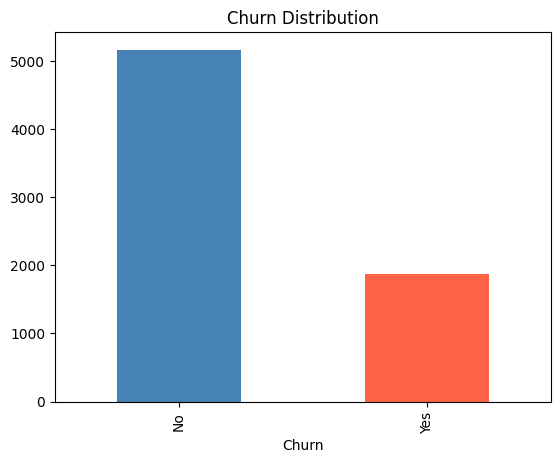

In [19]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.show()

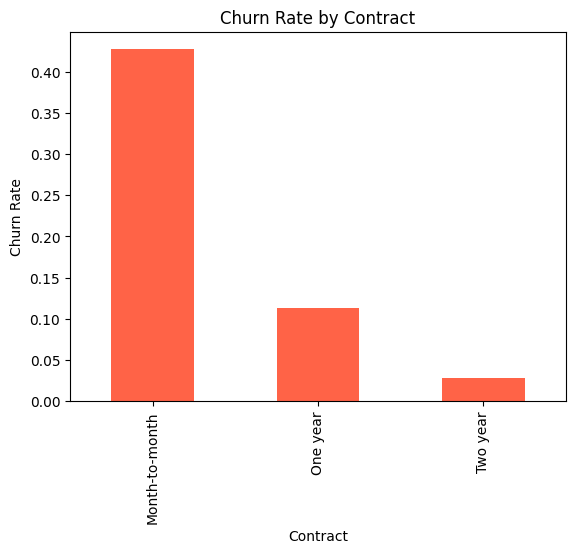

In [20]:
df.groupby('Contract')['Churn_binary'].mean().plot(kind='bar', color='tomato')
plt.title('Churn Rate by Contract')
plt.ylabel('Churn Rate')
plt.show()

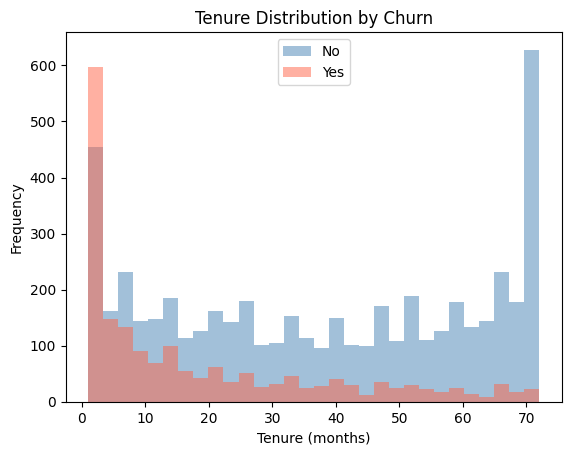

In [21]:
df[df['Churn']=='No']['tenure'].plot(kind='hist', alpha=0.5, label='No', color='steelblue', bins=30)
df[df['Churn']=='Yes']['tenure'].plot(kind='hist', alpha=0.5, label='Yes', color='tomato', bins=30)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend()
plt.show()

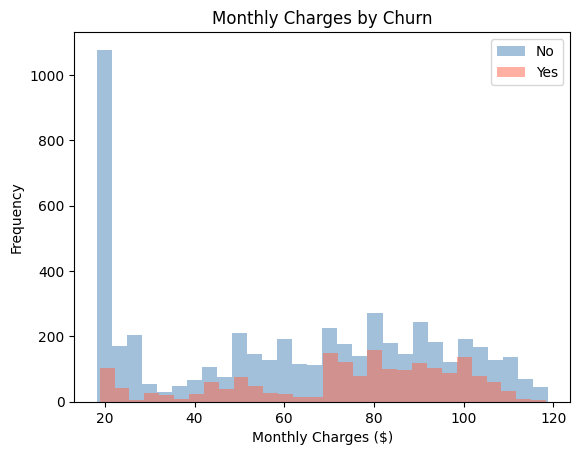

In [22]:
df[df['Churn']=='No']['MonthlyCharges'].plot(kind='hist', alpha=0.5, label='No', color='steelblue', bins=30)
df[df['Churn']=='Yes']['MonthlyCharges'].plot(kind='hist', alpha=0.5, label='Yes', color='tomato', bins=30)
plt.title('Monthly Charges by Churn')
plt.xlabel('Monthly Charges ($)')
plt.legend()
plt.show()

> **Tenure chart:** New customers (0-10 months) churn most frequently. After 2 years, churn drops sharply.  
> **Monthly charges chart:** Customers paying $60-110/month churn disproportionately — these are the fiber optic users.


## 5. Feature Engineering

Prepare data for machine learning:
- Encode target variable `Churn` as binary (Yes=1, No=0)
- Drop `customerID` (not useful for prediction) and original `Churn` column
- Apply `get_dummies` to convert all categorical columns to numeric (0/1)


In [23]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

cols_to_drop = ['customerID', 'Churn']
df_model = df.drop(columns=cols_to_drop)

df_model = pd.get_dummies(df_model, drop_first=True)
df_model.shape

(7032, 31)

> Dataset expanded from 21 to **31 columns** after encoding categorical variables.

## 6. Train / Test Split

Split data 80/20:
- **Train set (80%):** model learns patterns from these 5,625 customers
- **Test set (20%):** model is evaluated on 1,407 customers it has never seen


In [24]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns='Churn_binary')
y = df_model['Churn_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((5625, 30), (1407, 30))

## 7. Logistic Regression (Baseline)

Simple and interpretable model — good starting point for binary classification.


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
round(accuracy_score(y_test, y_pred), 3)

0.787

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



> **Results:**
> - Accuracy: **79%**
> - Recall for churners: **52%** — model catches about half of customers who will leave
> - The model is better at predicting who stays (recall 89%) than who leaves (recall 52%)
> - This is typical with class imbalance — churners are the minority class


## 8. Random Forest

Ensemble model — builds 100 decision trees and takes a majority vote.  
Often improves on logistic regression for complex datasets.


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



> **Comparison:**
>
> | Model | Accuracy | Precision (churn) | Recall (churn) |
> |---|---|---|---|
> | Logistic Regression | 0.787 | 0.62 | **0.52** |
> | Random Forest | 0.790 | 0.63 | 0.48 |
>
> **Logistic Regression** selected as final model — better recall on the churn class is more important for business.  
> Missing a churner is more costly than a false alarm.


### ROC-AUC Score
Measures how well the model separates the two classes overall (0.5 = random, 1.0 = perfect).

In [28]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
round(roc_auc_score(y_test, y_prob), 3)

np.float64(0.832)

> **ROC-AUC = 0.832** — good model performance. Well above random (0.5) and in the 'good' range (0.8+).

## 9. Business Impact

Translating model performance into real money.


In [29]:
avg_monthly = df['MonthlyCharges'].mean().round(2)
churners_missed = (y_test == 1).sum() - (y_pred == 1).sum()
monthly_loss = round(churners_missed * avg_monthly, 2)

print(f"Avg monthly charge: ${avg_monthly}")
print(f"Missed churners: {churners_missed}")
print(f"Monthly revenue at risk: ${monthly_loss}")

Avg monthly charge: $64.8
Missed churners: 63
Monthly revenue at risk: $4082.4


> ## 💰 Key Business Finding
>
> The model missed **63 churners** in the test set (20% of customers).  
> At $64.8 average monthly charge: **$4,082/month at risk** from test set alone.
>
> Scaled to full customer base (5x):  
> **~$245,000 per year** in preventable revenue loss.
>
> ### Recommended Actions:
> 1. **Target month-to-month customers** with long-term contract offers
> 2. **Investigate fiber optic satisfaction** — 42% churn rate is unsustainable  
> 3. **Focus retention on new customers (0-10 months)** — highest churn period
> 4. **Encourage autopay setup** — electronic check customers churn 3x more
